## Feature Importance Findings

The Random Forest feature importance analysis was used to identify which input features contributed most to the model's predictions.

The importance values were aggregated from the one-hot encoded variables back to their original features. This allows the contribution of categorical variables such as commodity, market, and administrative location to be evaluated as groups.

The most important features were identified based on their aggregated importance values. These findings help explain which characteristics of agricultural commodity observations are most useful for predicting market prices.

In [17]:
total_importance = grouped_importance["Importance (%)"].sum()

print(f"Total Feature Importance: {total_importance:.2f}%")

Total Feature Importance: 100.00%


In [16]:
top_5_features = grouped_importance.head(5)

top_5_features
print("Top 5 Most Important Features")
print("--------------------------------")

for i, row in top_5_features.iterrows():
    print(
        f"{i + 1}. {row['Original Feature']}: "
        f"{row['Importance (%)']:.2f}%"
    )

Top 5 Most Important Features
--------------------------------
1. commodity: 47.77%
2. category: 30.76%
3. unit: 5.74%
4. year: 5.72%
5. market: 2.43%


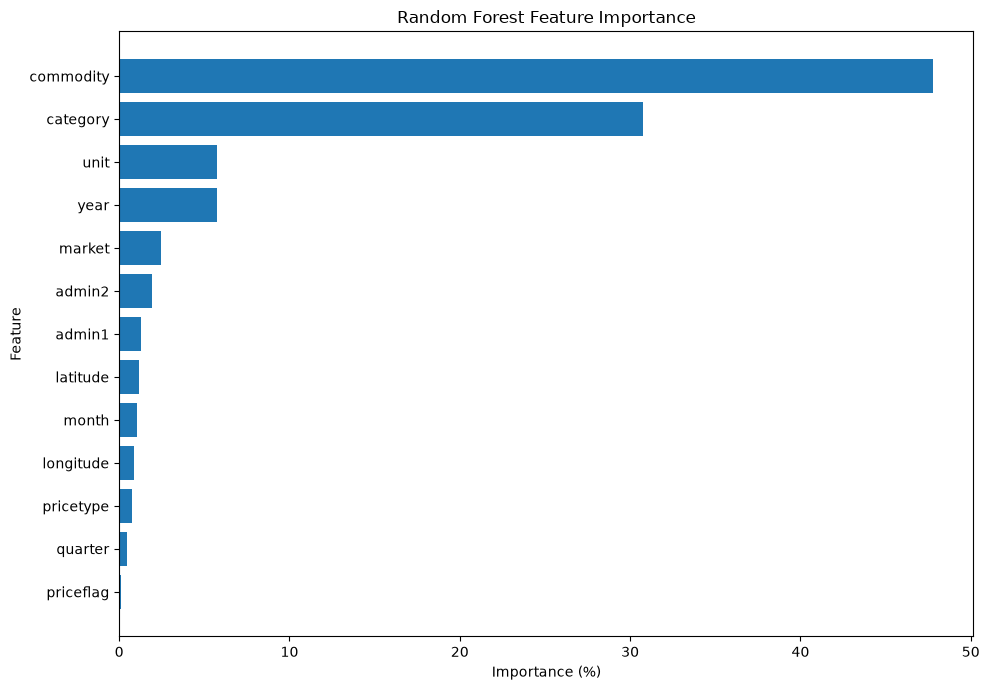

In [14]:
plot_data = grouped_importance.sort_values(
    "Importance (%)",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Original Feature"],
    plot_data["Importance (%)"]
)

plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [13]:
grouped_importance = grouped_importance[
    ["Original Feature", "Importance (%)"]
]

grouped_importance

,Original Feature,Importance (%)
0,commodity,47.767083
1,category,30.755503
2,unit,5.741085
3,year,5.717689
4,market,2.427124
5,admin2,1.939243
6,admin1,1.264974
7,latitude,1.193362
8,month,1.024199
9,longitude,0.858006


In [12]:
grouped_importance["Importance (%)"] = (
    grouped_importance["Importance"] * 100
)

grouped_importance

,Original Feature,Importance,Importance (%)
0,commodity,0.477671,47.767083
1,category,0.307555,30.755503
2,unit,0.057411,5.741085
3,year,0.057177,5.717689
4,market,0.024271,2.427124
5,admin2,0.019392,1.939243
6,admin1,0.012650,1.264974
7,latitude,0.011934,1.193362
8,month,0.010242,1.024199
9,longitude,0.008580,0.858006


In [11]:
grouped_importance = (
    importance_df
    .groupby("Original Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

grouped_importance

,Original Feature,Importance
0,commodity,0.477671
1,category,0.307555
2,unit,0.057411
3,year,0.057177
4,market,0.024271
5,admin2,0.019392
6,admin1,0.012650
7,latitude,0.011934
8,month,0.010242
9,longitude,0.008580


In [10]:
def get_original_feature(encoded_name):
    name = encoded_name.split("__", 1)[-1]

    for feature in original_features:
        if name == feature or name.startswith(feature + "_"):
            return feature

    return name


importance_df["Original Feature"] = (
    importance_df["Feature"]
    .apply(get_original_feature)
)

importance_df.head(20)

,Feature,Importance,Original Feature
0,"categorical__category_meat, fish and eggs",0.203428,category
1,categorical__commodity_Shrimp (tiger),0.157596,commodity
2,numerical__year,0.057177,year
3,categorical__category_vegetables and fruits,0.051853,category
4,categorical__commodity_Meat (beef),0.048395,commodity
5,categorical__category_cereals and tubers,0.047510,category
6,categorical__unit_Unit,0.030263,unit
7,categorical__unit_KG,0.027101,unit
8,"categorical__commodity_Meat (beef, chops with ...",0.025279,commodity
9,categorical__commodity_Crab,0.023567,commodity


In [9]:
original_features = [
    "admin1",
    "admin2",
    "market",
    "latitude",
    "longitude",
    "category",
    "commodity",
    "unit",
    "priceflag",
    "pricetype",
    "year",
    "month",
    "quarter"
]

print("Original features:", len(original_features))

Original features: 13


In [8]:
top_encoded = importance_df.head(20)

top_encoded

,Feature,Importance
0,"categorical__category_meat, fish and eggs",0.203428
1,categorical__commodity_Shrimp (tiger),0.157596
2,numerical__year,0.057177
3,categorical__category_vegetables and fruits,0.051853
4,categorical__commodity_Meat (beef),0.048395
5,categorical__category_cereals and tubers,0.047510
6,categorical__unit_Unit,0.030263
7,categorical__unit_KG,0.027101
8,"categorical__commodity_Meat (beef, chops with ...",0.025279
9,categorical__commodity_Crab,0.023567


In [7]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

importance_df.head(20)

,Feature,Importance
0,"categorical__category_meat, fish and eggs",0.203428
1,categorical__commodity_Shrimp (tiger),0.157596
2,numerical__year,0.057177
3,categorical__category_vegetables and fruits,0.051853
4,categorical__commodity_Meat (beef),0.048395
5,categorical__category_cereals and tubers,0.047510
6,categorical__unit_Unit,0.030263
7,categorical__unit_KG,0.027101
8,"categorical__commodity_Meat (beef, chops with ...",0.025279
9,categorical__commodity_Crab,0.023567


In [6]:
importances = rf_model.feature_importances_

print("Number of importance values:", len(importances))
print("Number of feature names:", len(feature_names))

Number of importance values: 297
Number of feature names: 297


In [5]:
feature_names = preprocessor.get_feature_names_out()

print("Number of encoded features:", len(feature_names))
print("\nFirst 20 features:")

for feature in feature_names[:20]:
    print(feature)

Number of encoded features: 297

First 20 features:
categorical__admin1_Autonomous region in Muslim Mindanao
categorical__admin1_Cordillera Administrative region
categorical__admin1_National Capital region
categorical__admin1_Region I
categorical__admin1_Region II
categorical__admin1_Region III
categorical__admin1_Region IV-A
categorical__admin1_Region IV-B
categorical__admin1_Region IX
categorical__admin1_Region V
categorical__admin1_Region VI
categorical__admin1_Region VII
categorical__admin1_Region VIII
categorical__admin1_Region X
categorical__admin1_Region XI
categorical__admin1_Region XII
categorical__admin1_Region XIII
categorical__admin2_Abra
categorical__admin2_Agusan del Norte
categorical__admin2_Agusan del Sur


In [4]:
preprocessor = model.named_steps["preprocessor"]
rf_model = model.named_steps["model"]

print("Preprocessor:", type(preprocessor).__name__)
print("Model:", type(rf_model).__name__)

Preprocessor: ColumnTransformer
Model: RandomForestRegressor


In [3]:
print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['admin1', 'admin2', 'market',
                                                   'category', 'commodity',
                                                   'unit', 'priceflag',
                                                   'pricetype']),
                                                 ('numerical', 'passthrough',
                                                  ['latitude', 'longitude',
                                                   'year', 'month',
                                                   'quarter'])])),
                ('model',
                 RandomForestRegressor(max_features='sqrt', n_jobs=-1,
                                       random_state=42))])


In [2]:
model_path = "../models/best_model.joblib"

model = joblib.load(model_path)

print("Model loaded successfully.")

Model loaded successfully.


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# Feature Importance Analysis

This notebook analyzes the feature importance of the final Random Forest regression model.

The purpose is to determine which input features contribute most to the model's agricultural commodity price predictions.